In [2]:
import requests
import pandas as pd
import os
import json
from dotenv import load_dotenv

In [3]:
# Install dependencies as needed:
!pip install kagglehub[pandas-datasets]


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
df = pd.read_csv(r"C:\Users\joshu\Downloads\sleep_doomscrolling_habits.csv")
df.head()

,respondent_id,age,bedtime_screen_time_minutes,total_daily_screen_time_hours,doomscroll_sessions_per_night,avg_doomscroll_session_minutes,sleep_hours_per_night,sleep_latency_minutes,number_of_night_wakeups,caffeine_intake_mg_per_day,...,occupation_status,country_region,primary_device_used_at_night,bedtime_routine_type,uses_night_mode,keeps_phone_in_bedroom,consumes_negative_news_content,uses_sleep_tracking_app,doomscroller,sleep_quality_category
0,D30000,22,13.0,1.85,2,5.4,8.1,19.0,2,155.0,...,Unemployed,Germany,Tablet,Meditation/Journaling,Yes,Yes,Yes,No,Yes,Good
1,D30001,18,90.0,3.61,3,29.6,7.0,31.0,3,82.0,...,Student,India,Smartphone,Meditation/Journaling,No,Yes,Yes,No,Yes,Poor
2,D30002,37,51.0,5.15,3,15.5,7.1,24.0,2,49.0,...,Student,India,Laptop,Reading,No,Yes,No,Yes,Yes,Fair
3,D30003,27,53.0,3.74,0,51.4,8.4,35.0,0,42.0,...,NaN,United States,Smartphone,No Fixed Routine,No,Yes,Yes,No,No,Fair
4,D30004,17,67.0,6.09,2,32.2,7.2,19.0,1,76.0,...,Employed Part-time,United States,Smartphone,Watching Videos,No,No,No,No,No,Fair


In [5]:
needed_columns = [
    "age",
    "bedtime_screen_time_minutes",
    "sleep_hours_per_night",
    "sleep_quality_category"

]
df = df[needed_columns]
df.head()

,age,bedtime_screen_time_minutes,sleep_hours_per_night,sleep_quality_category
0,22,13.0,8.1,Good
1,18,90.0,7.0,Poor
2,37,51.0,7.1,Fair
3,27,53.0,8.4,Fair
4,17,67.0,7.2,Fair


In [6]:
df.tail()

,age,bedtime_screen_time_minutes,sleep_hours_per_night,sleep_quality_category
995,26,85.0,7.6,Poor
996,23,3.0,7.5,Fair
997,15,28.0,9.2,Good
998,22,23.0,6.9,Fair
999,23,35.0,7.5,Fair


In [7]:
df.dtypes

age                              int64
bedtime_screen_time_minutes    float64
sleep_hours_per_night          float64
sleep_quality_category             str
dtype: object

In [9]:
X = df.drop('bedtime_screen_time_minutes', axis=1).values
y = df['bedtime_screen_time_minutes'].values
print(type(X), type(y))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [10]:
X_sleep_hours_per_night = X[:, 0].reshape(-1, 1)
print(y.shape, X_sleep_hours_per_night.shape)

(1000,) (1000, 1)


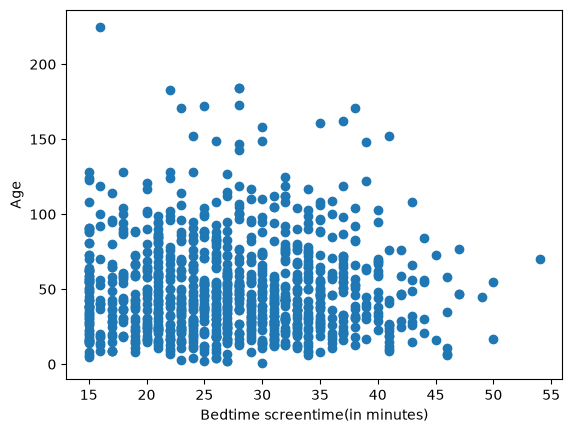

In [11]:
import matplotlib.pyplot as plt
plt.scatter(X_sleep_hours_per_night, y)
plt.ylabel("Bedtime screentime(in minutes)")
plt.xlabel("Bedtime screentime(in minutes)")
plt.show()

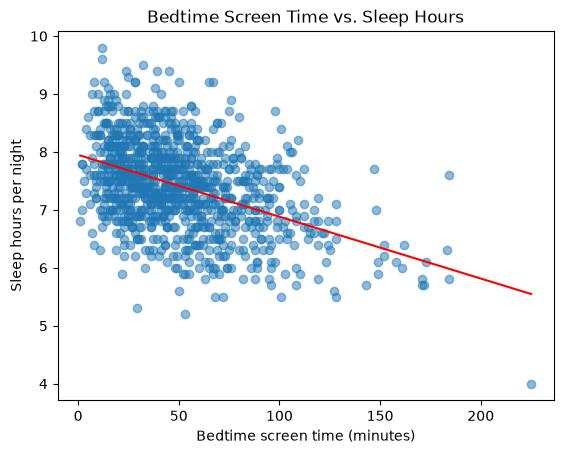

In [13]:
from sklearn.linear_model import LinearRegression

X_bedtime_screen = df[["bedtime_screen_time_minutes"]]
y_sleep_hours = df["sleep_hours_per_night"]

sleep_model = LinearRegression()
sleep_model.fit(X_bedtime_screen, y_sleep_hours)

# Sort x-values so the regression line is drawn smoothly
plot_data = df.sort_values("bedtime_screen_time_minutes")
sleep_predictions = sleep_model.predict(
    plot_data[["bedtime_screen_time_minutes"]]
)

plt.scatter(X_bedtime_screen, y_sleep_hours, alpha=0.5)
plt.plot(
    plot_data["bedtime_screen_time_minutes"],
    sleep_predictions,
    color="red"
)
plt.xlabel("Bedtime screen time (minutes)")
plt.ylabel("Sleep hours per night")
plt.title("Bedtime Screen Time vs. Sleep Hours")
plt.show()

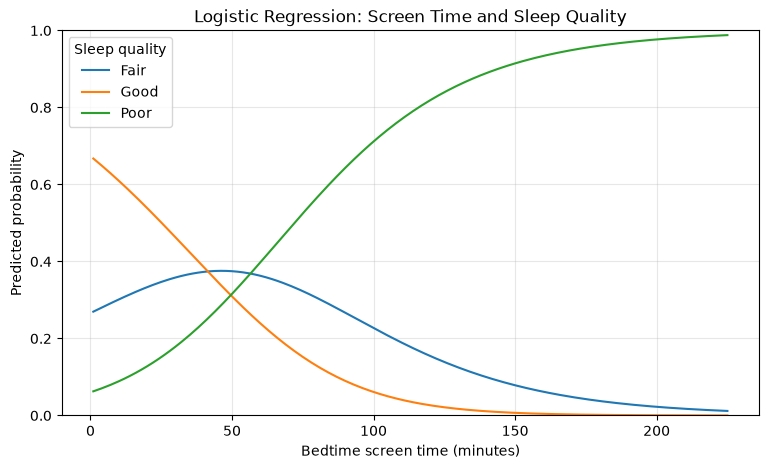

In [18]:
from sklearn.linear_model import LogisticRegression

feature = "bedtime_screen_time_minutes"
target = "sleep_quality_category"

screen_quality_model = LogisticRegression(max_iter=1000)
screen_quality_model.fit(df[[feature]], df[target])

# Predict category probabilities across the observed screen-time range
screen_grid = pd.DataFrame({
    feature: range(
        int(df[feature].min()),
        int(df[feature].max()) + 1
    )
})
probabilities = screen_quality_model.predict_proba(screen_grid)

plt.figure(figsize=(9, 5))
for i, category in enumerate(screen_quality_model.classes_):
    plt.plot(
        screen_grid[feature],
        probabilities[:, i],
        label=category
    )

plt.xlabel("Bedtime screen time (minutes)")
plt.ylabel("Predicted probability")
plt.title("Logistic Regression: Screen Time and Sleep Quality")
plt.ylim(0, 1)
plt.legend(title="Sleep quality")
plt.grid(alpha=0.3)
plt.show()